In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, accuracy_score

Generate abnormal dataset - increease churn rate by 5%,plot roc curve

## Load Data


In [62]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

## Clean TotalCharges (Convert blank strings to NaN, then fill with median)

In [63]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

### Define X and y AFTER cleaning missing values

In [64]:
X = df.drop(columns=['customerID', 'Churn'])
y = (df['Churn'] == 'Yes').astype(int)

### Separate Numerical and Categorical columns

In [65]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
cat_cols = [col for col in X.columns if col not in num_cols]

### Train-Test Split

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Create Preprocessor Pipeline

In [67]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ]
)

### Define Pipeline and Train model

In [68]:
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

### Extract feature names after One-Hot Encoding

In [70]:
cat_encoder = model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_cols = list(cat_encoder.get_feature_names_out(cat_cols))
all_feature_names = num_cols + encoded_cat_cols

### Extract model weights

In [71]:
coefficients = model_pipeline.named_steps['classifier'].coef_[0]

### Build summary df

In [73]:
coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients,
    'Odds_Ratio': np.exp(coefficients)
}).sort_values(by='Coefficient', ascending=False)

print(coef_df)

                                  Feature  Coefficient  Odds_Ratio
10            InternetService_Fiber optic     1.198969    3.316695
2                            TotalCharges     0.513307    1.670807
21                        StreamingTV_Yes     0.383166    1.466921
23                    StreamingMovies_Yes     0.382559    1.466031
28         PaymentMethod_Electronic check     0.381118    1.463920
26                   PaperlessBilling_Yes     0.372901    1.451941
9                       MultipleLines_Yes     0.364684    1.440059
29             PaymentMethod_Mailed check     0.072411    1.075097
3                           SeniorCitizen     0.054616    1.056135
17                   DeviceProtection_Yes     0.037949    1.038679
4                             gender_Male     0.023420    1.023696
5                             Partner_Yes     0.022384    1.022636
27  PaymentMethod_Credit card (automatic)    -0.031459    0.969030
15                       OnlineBackup_Yes    -0.094796    0.90

### Evaluation

In [85]:

y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]
acc = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_proba)

print(f"\nAccuracy: {acc:.4f}")
print(f"ROC-AUC:  {auc_score:.4f}\n")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


Accuracy: 0.8055
ROC-AUC:  0.8420

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### Plot rac curve, Generate abnormal dataset - increease churn rate by 5%,plot roc curve

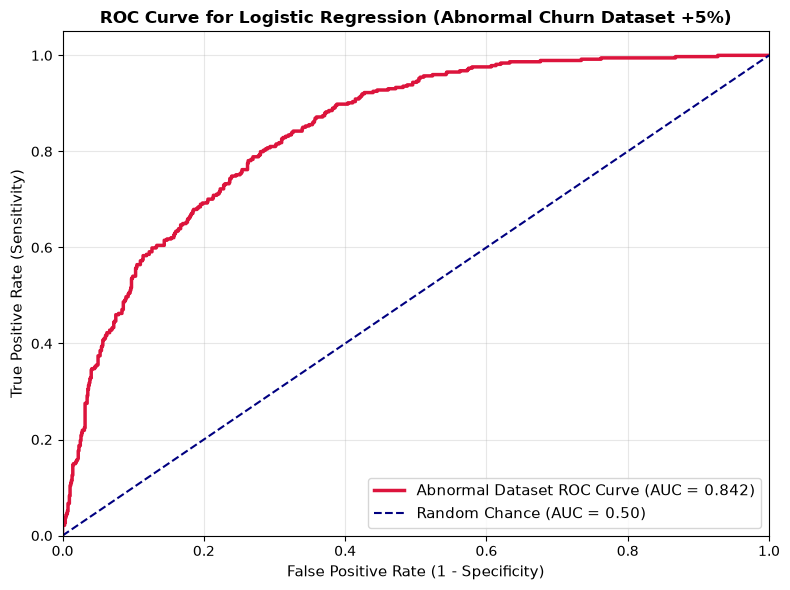

In [86]:

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='crimson', lw=2.5, label=f'Abnormal Dataset ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Chance (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11)
plt.title('ROC Curve for Logistic Regression (Abnormal Churn Dataset +5%)', fontsize=12, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('abnormal_churn_roc_curve.png')
plt.show()